In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = ChatGroq(model="qwen/qwen3-32b")

In [4]:
from pydantic import BaseModel
from typing import Optional

class State(BaseModel):
    topic: Optional[str] = None
    characters: Optional[str] = None
    settings: Optional[str] = None
    premises: Optional[str] = None
    story_intro: Optional[str] = None

In [7]:
## Nodes

def generate_character(state: State):
    """Generate Character details about the story"""
    return {"characters": llm.invoke(f"Create two character names and brief traits for a story about {state.topic}").content}

def generate_setting(state: State):
    """Generate settings about the story"""
    return {"settings": llm.invoke(f"Describe a vivid setting for a story about {state.topic}").content}

def generate_premise(state: State):
    """Generate premise about the story"""
    return {"premises": llm.invoke(f"Write a one-sentence plot premise for a story about {state.topic}").content}

def combine_elements(state: State):
    """Combine characters, setting, premises into an intro"""
    msg = llm.invoke(f"""
    Write a short story introduction using these elements:
    Characters: {state.characters}
    Settings: {state.settings}
    Premises: {state.premises}
    """)
    return {"story_intro": msg.content}


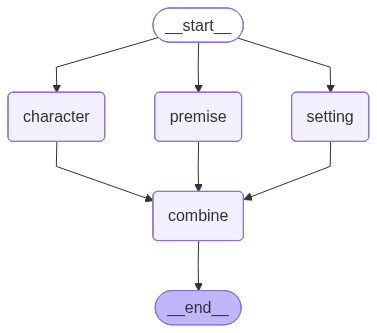

In [16]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

builder = StateGraph(State)

builder.add_node("character", generate_character)
builder.add_node("setting", generate_setting)
builder.add_node("premise", generate_premise)
builder.add_node("combine", combine_elements)


builder.add_edge(START, "character")
builder.add_edge(START, "setting")
builder.add_edge(START, "premise")
builder.add_edge("character", "combine")
builder.add_edge("setting", "combine")
builder.add_edge("premise", "combine")
builder.add_edge("combine", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
state = {"topic": "Time Travel"}
graph.invoke(state)

{'topic': 'Time Travel',
 'characters': '<think>\nOkay, the user wants me to create two character names and their brief traits for a time-travel story. Let me start by thinking about what makes time-travel characters interesting. They need distinct personalities that can create conflict or complement each other. Maybe one could be the cautious, rule-following type, while the other is more reckless or idealistic. That contrast could drive the story.\n\nFirst, names. For a time-travel story, maybe something that sounds a bit timeless or has a classic feel. Maybe a mix of traditional and modern? Let me brainstorm. For the first character, maybe a male and a female? Or maybe two males or two females? The user didn\'t specify, so I\'ll go with a mix. Let\'s see... A name like "Elias" feels classic. Pair it with a surname that has a techy or scientific vibe. "Chronos" maybe? But that\'s too on-the-nose. Maybe "Cronin"? Sounds like Cronus but more approachable. Elias Cronin. Now, his traits. 